> **Completed run.** This copy of the notebook was run end to end on 30 September 2026 with its default settings and data from the Hugging Face Hub, so you can read every output without running it (every cell ran; 72 minutes). It was run on an Apple M1 Pro rather than a Colab T4: the installs were skipped and QLoRA ran as LoRA in bfloat16, because 4-bit quantisation needs an NVIDIA GPU. Your results on Colab will differ slightly.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aims-ai-research-foundations/airf-capstone-project-recipes/blob/main/projects/customer-support-assistant/notebook.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-black?logo=github)](https://github.com/aims-ai-research-foundations/airf-capstone-project-recipes/blob/main/projects/customer-support-assistant/notebook.ipynb)
[![Dataset](https://img.shields.io/badge/Dataset-Hugging%20Face-yellow?logo=huggingface)](https://huggingface.co/datasets/Similoluwa/capstone-datasets/viewer/customer_support)

# Build a Customer Support Intent Classifier

**Project Category:** Classification

## Problem

Support teams receive thousands of customer queries a day, and each one must be routed to the right team quickly and correctly.

## What You'll Build

A small language model (Gemma 1B) that predicts the intent of a customer support message, compared across zero-shot prompting, few-shot prompting and QLoRA fine-tuning.

## Research Question

> How much does a small language model gain from examples in its prompt, and from fine-tuning, when classifying customer intents?

## What You'll Learn

- Prompt a language model for zero-shot classification over a fixed label set
- Add labelled examples to the prompt (few-shot prompting)
- Fine-tune Gemma with QLoRA (a 4-bit base model with LoRA adapters) on a single T4 GPU
- Compare approaches overall and per intent, and analyse their confusions

## Setup

- Create a free Hugging Face account at [huggingface.co/join](https://huggingface.co/join).
- Accept the Gemma licence on the [Gemma 3 1B](https://huggingface.co/google/gemma-3-1b-it) and [Gemma 3 4B](https://huggingface.co/google/gemma-3-4b-it) model pages.
- Create a Hugging Face access token ([settings/tokens](https://huggingface.co/settings/tokens), **Read** access) and add it to Google Colab Secrets as `HF_TOKEN`, with notebook access turned on.
- Open the notebook in Google Colab.
- Enable a GPU under **Runtime → Change runtime type → T4 GPU**.

---

## Install Required Libraries

In [ ]:
!pip install -q --progress-bar off transformers==5.17.0 datasets==5.0.1 accelerate==1.15.0 peft==0.21.0 trl==1.14.0 bitsandbytes scikit-learn

## Import Libraries

In [2]:
import gc
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import torch
import transformers
from datasets import Dataset, load_dataset
from huggingface_hub import login
from peft import LoraConfig
from sklearn.metrics import accuracy_score, classification_report, f1_score
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, Pipeline, pipeline
from trl import SFTConfig, SFTTrainer

site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Log in to Hugging Face so the gated Gemma models can be downloaded.
try:
    from google.colab import userdata

    login(token=userdata.get("HF_TOKEN"))
except ImportError:
    pass  # Outside Colab, run `hf auth login` once in a terminal instead.

## Settings

In [4]:
MODEL_ID = "google/gemma-3-1b-it"
BATCH_SIZE = 16
SEED = 42

## Helpers

Reusable functions used in the experiment below. Read them to see how each step works.

In [5]:
transformers.logging.set_verbosity_error()  # Hide repeated generation-config warnings.


def load_chat_model(model_id: str) -> Pipeline:
    """Loads a Gemma chat model as a text-generation pipeline."""
    pipe = pipeline("text-generation", model=model_id, dtype=torch.bfloat16, device_map="auto")
    pipe.tokenizer.padding_side = "left"  # Decoder-only models must be left-padded for batching.
    return pipe


def generate(
    pipe: Pipeline,
    prompts: list[str],
    max_new_tokens: int,
    batch_size: int = 8,
    temperature: float = 0.0,
) -> list[str]:
    """Generates one chat reply per prompt in batches (greedy unless a temperature is given)."""
    sampling = (
        {"do_sample": True, "temperature": temperature} if temperature > 0 else {"do_sample": False}
    )
    replies = []
    for i in tqdm(range(0, len(prompts), batch_size)):
        chats = [[{"role": "user", "content": p}] for p in prompts[i : i + batch_size]]
        outputs = pipe(chats, max_new_tokens=max_new_tokens, batch_size=batch_size, **sampling)
        replies += [o[0]["generated_text"][-1]["content"].strip() for o in outputs]
    return replies


def parse_label(reply: str, labels: list[str]) -> str:
    """Maps a model reply to a valid label, or 'invalid' if none is found."""
    text = re.sub(r"[^a-z0-9_]+", "_", reply.lower()).strip("_")
    if text in labels:
        return text
    found = [label for label in labels if label in text]
    return max(found, key=len) if found else "invalid"


def classification_metrics(
    y_true: list[str], y_pred: list[str], labels: list[str]
) -> dict[str, float]:
    """Computes accuracy, macro-F1 and the share of invalid predictions."""
    present = [
        label for label in labels if label in set(y_true)
    ]  # 'invalid' and absent classes do not count
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, labels=present, average="macro", zero_division=0),
        "Invalid outputs": sum(p == "invalid" for p in y_pred) / len(y_pred),
    }


def per_intent_f1(y_true: list[str], y_pred: list[str], labels: list[str]) -> pd.Series:
    """Returns the F1 score of each intent."""
    report = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    return pd.Series({label: report[label]["f1-score"] for label in labels})


def top_confusions(y_true: list[str], y_pred: list[str], n: int = 10) -> pd.DataFrame:
    """Lists the most frequent (true intent, predicted intent) mistakes."""
    pairs = Counter((t, p) for t, p in zip(y_true, y_pred) if t != p)
    return pd.DataFrame(
        [(t, p, c) for (t, p), c in pairs.most_common(n)],
        columns=["True intent", "Predicted", "Count"],
    )

## Load Dataset

BANKING77: online-banking customer queries, each labelled with one of 77 intents.

In [6]:
dataset = load_dataset(
    "Similoluwa/capstone-datasets",
    "customer_support",
    revision="v5.0",
)

dataset

Generating train split:   0%|          | 0/8951 [00:00<?, ? examples/s]

Generating train split: 100%|██████████| 8951/8951 [00:00<00:00, 735089.29 examples/s]

Generating validation split:   0%|          | 0/995 [00:00<?, ? examples/s]

Generating validation split: 100%|██████████| 995/995 [00:00<00:00, 286354.64 examples/s]

Generating test split:   0%|          | 0/3075 [00:00<?, ? examples/s]

Generating test split: 100%|██████████| 3075/3075 [00:00<00:00, 631177.68 examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text', 'language', 'in_small_test', 'source'],
        num_rows: 8951
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text', 'language', 'in_small_test', 'source'],
        num_rows: 995
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text', 'language', 'in_small_test', 'source'],
        num_rows: 3075
    })
})

In [7]:
LABELS = dataset["train"].features["label"].names
train = dataset["train"].to_pandas()
validation = dataset["validation"].to_pandas()
test = dataset["test"].to_pandas()

print(len(LABELS), "intents, e.g.", LABELS[:5])
train.sample(5, random_state=SEED)[["text", "label_text"]]

77 intents, e.g. ['activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up']


,text,label_text
2531,My wallet was taken and I see that someone is ...,cash_withdrawal_not_recognised
6127,I made a purchase recently but I have decided ...,request_refund
4438,How can I create a disposable virtual card?,get_disposable_virtual_card
4123,There is some odd 1£ charge that appears as pe...,extra_charge_on_statement
3480,Weird Direct Debit payment,direct_debit_payment_not_recognised


Generation is slow, so all three approaches are compared on `in_small_test`: 10 test queries per intent (770 queries).

In [8]:
small_test = test[test["in_small_test"]].reset_index(drop=True)

## Build and Run the Model

```text
Zero-shot   prompt = task + list of 77 intents + query
Few-shot    prompt = task + one example query per intent + query
QLoRA       Gemma fine-tuned on 8,951 labelled queries; prompt = task + query
```

### Zero-shot and few-shot prompting

In [9]:
ZERO_SHOT_PROMPT = """Classify this online-banking customer query into exactly one intent.

Intents: {labels}

Query: {text}

Reply with the intent name only."""

FEW_SHOT_PROMPT = """Classify this online-banking customer query into exactly one intent.
Here is one example query for each intent:

{examples}

Query: {text}

Reply with the intent name only."""

# One training example per intent, chosen with a fixed seed.
shots = train.groupby("label_text").sample(1, random_state=SEED)
examples = "\n".join(f"{row.label_text}: {row.text}" for row in shots.itertuples())

pipe = load_chat_model(MODEL_ID)
prompts = {
    "zero_shot": [
        ZERO_SHOT_PROMPT.format(labels=", ".join(LABELS), text=t) for t in small_test["text"]
    ],
    "few_shot": [FEW_SHOT_PROMPT.format(examples=examples, text=t) for t in small_test["text"]],
}
for name, batch in prompts.items():
    replies = generate(pipe, batch, max_new_tokens=16, batch_size=BATCH_SIZE)
    small_test[name] = [parse_label(r, LABELS) for r in replies]

small_test[["text", "label_text", "zero_shot", "few_shot"]].head()

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/340 [00:00<00:41,  8.16it/s]

Loading weights:  35%|███▍      | 118/340 [00:00<00:00, 632.36it/s]

Loading weights:  68%|██████▊   | 232/340 [00:00<00:00, 851.56it/s]

Loading weights: 100%|██████████| 340/340 [00:00<00:00, 817.37it/s]

...

 96%|█████████▌| 47/49 [21:02<00:53, 26.95s/it]

 98%|█████████▊| 48/49 [21:29<00:26, 26.91s/it]

100%|██████████| 49/49 [21:32<00:00, 19.91s/it]

100%|██████████| 49/49 [21:32<00:00, 26.38s/it]

,text,label_text,zero_shot,few_shot
0,How can I activate my card so I can start usin...,activate_my_card,activate_my_card,activate_my_card
1,How can I activate my card>,activate_my_card,activate_my_card,activate_my_card
2,"I just got my card and want to use it, how do ...",activate_my_card,activate_my_card,activate_my_card
3,I just got this card & I don't know how to act...,activate_my_card,activate_my_card,activate_my_card
4,I need help activating my new card.,activate_my_card,activate_my_card,activate_my_card


In [10]:
# Free GPU memory before loading the next model.
del pipe
gc.collect()
torch.cuda.empty_cache()

### QLoRA fine-tuning

The base model is loaded in 4-bit precision and only small LoRA adapter matrices are trained. After fine-tuning, the model no longer needs the list of intents or examples in its prompt.

In [11]:
FT_PROMPT = "Classify this online-banking customer query into its intent.\n\nQuery: {text}"


def to_chat(df: pd.DataFrame) -> Dataset:
    """Converts queries and intents into prompt-completion chat examples."""
    return Dataset.from_list(
        [
            {
                "prompt": [{"role": "user", "content": FT_PROMPT.format(text=t)}],
                "completion": [{"role": "assistant", "content": label}],
            }
            for t, label in zip(df["text"], df["label_text"])
        ]
    )


train_chat, validation_chat = to_chat(train), to_chat(validation)
train_chat[0]

{'prompt': [{'role': 'user',
   'content': 'Classify this online-banking customer query into its intent.\n\nQuery: Activate my card'}],
 'completion': [{'role': 'assistant', 'content': 'activate_my_card'}]}

In [12]:
# 4-bit quantisation needs a CUDA GPU; T4s lack native bfloat16, so compute runs in float32 there.
compute_dtype = (
    torch.bfloat16 if torch.cuda.is_bf16_supported(including_emulation=False) else torch.float32
)
quantization = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=compute_dtype
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=quantization, dtype=compute_dtype, device_map="auto"
)

trainer = SFTTrainer(
    model=model,
    args=SFTConfig(
        output_dir="gemma-banking77-qlora",
        num_train_epochs=1,
        per_device_train_batch_size=16,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        warmup_steps=0.03,  # a float below 1 is a fraction of all training steps
        max_length=160,  # longer examples are cut; 160 tokens fits every query and label
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        seed=SEED,
    ),
    train_dataset=train_chat,
    eval_dataset=validation_chat,
    processing_class=tokenizer,
    peft_config=LoraConfig(
        r=16, lora_alpha=32, lora_dropout=0.05, target_modules="all-linear", task_type="CAUSAL_LM"
    ),
)
trainer.train()

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/340 [00:00<00:36,  9.26it/s]

Loading weights:  28%|██▊       | 96/340 [00:00<00:00, 542.46it/s]

Loading weights:  45%|████▍     | 152/340 [00:00<00:00, 495.89it/s]

Loading weights:  60%|█████▉    | 203/340 [00:00<00:00, 418.50it/s]

...

{'loss': '0.05521', 'grad_norm': '1.139', 'learning_rate': '1.992e-05', 'entropy': '0.04814', 'num_tokens': '3.319e+05', 'mean_token_accuracy': '0.9847', 'epoch': '0.8036'}


{'loss': '0.04485', 'grad_norm': '0.5207', 'learning_rate': '6.163e-06', 'entropy': '0.04178', 'num_tokens': '3.685e+05', 'mean_token_accuracy': '0.9865', 'epoch': '0.8929'}


{'loss': '0.04872', 'grad_norm': '0.5837', 'learning_rate': '2.024e-07', 'entropy': '0.03935', 'num_tokens': '4.056e+05', 'mean_token_accuracy': '0.9868', 'epoch': '0.9821'}


{'eval_loss': '0.0499', 'eval_runtime': '73.99', 'eval_samples_per_second': '13.45', 'eval_steps_per_second': '1.689', 'eval_entropy': '0.04254', 'eval_num_tokens': '4.124e+05', 'eval_mean_token_accuracy': '0.9845', 'epoch': '1'}
{'train_runtime': '2494', 'train_samples_per_second': '3.589', 'train_steps_per_second': '0.225', 'train_loss': '0.2596', 'epoch': '1'}


TrainOutput(global_step=560, training_loss=0.2596105438257967, metrics={'train_runtime': 2494.0682, 'train_samples_per_second': 3.589, 'train_steps_per_second': 0.225, 'train_loss': 0.2596105438257967, 'epoch': 1.0})

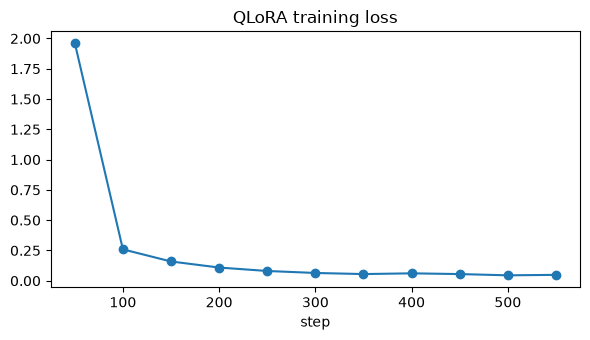

In [13]:
log = pd.DataFrame(trainer.state.log_history).dropna(subset=["loss"])
log.plot(
    x="step", y="loss", marker="o", legend=False, figsize=(6, 3.5), title="QLoRA training loss"
)
plt.tight_layout()

In [14]:
# Training switches the key-value cache off; turn it back on, or generation becomes very slow.
trainer.model.config.use_cache = True
trainer.model.eval()  # Switch off dropout for deterministic generation.
tokenizer.padding_side = "left"
fine_tuned = pipeline("text-generation", model=trainer.model, tokenizer=tokenizer)
replies = generate(
    fine_tuned,
    [FT_PROMPT.format(text=t) for t in small_test["text"]],
    max_new_tokens=16,
    batch_size=BATCH_SIZE,
)
small_test["qlora"] = [parse_label(r, LABELS) for r in replies]

  0%|          | 0/49 [00:00<?, ?it/s]

  2%|▏         | 1/49 [00:01<01:07,  1.41s/it]

  4%|▍         | 2/49 [00:03<01:16,  1.63s/it]

  6%|▌         | 3/49 [00:04<01:09,  1.50s/it]

  8%|▊         | 4/49 [00:07<01:28,  1.96s/it]

...

 94%|█████████▍| 46/49 [01:23<00:05,  1.74s/it]

 96%|█████████▌| 47/49 [01:25<00:03,  1.80s/it]

 98%|█████████▊| 48/49 [01:27<00:01,  1.91s/it]

100%|██████████| 49/49 [01:28<00:00,  1.62s/it]

100%|██████████| 49/49 [01:28<00:00,  1.81s/it]

## Evaluate

In [15]:
approaches = {
    "Zero-shot": "zero_shot",
    "Few-shot (1 example per intent)": "few_shot",
    "QLoRA fine-tuned": "qlora",
}
results = pd.DataFrame(
    {
        name: classification_metrics(
            small_test["label_text"].tolist(), small_test[col].tolist(), LABELS
        )
        for name, col in approaches.items()
    }
).T
results.round(3)

,Accuracy,Macro-F1,Invalid outputs
Zero-shot,0.238,0.219,0.260
Few-shot (1 example per intent),0.214,0.225,0.423
QLoRA fine-tuned,0.917,0.918,0.003


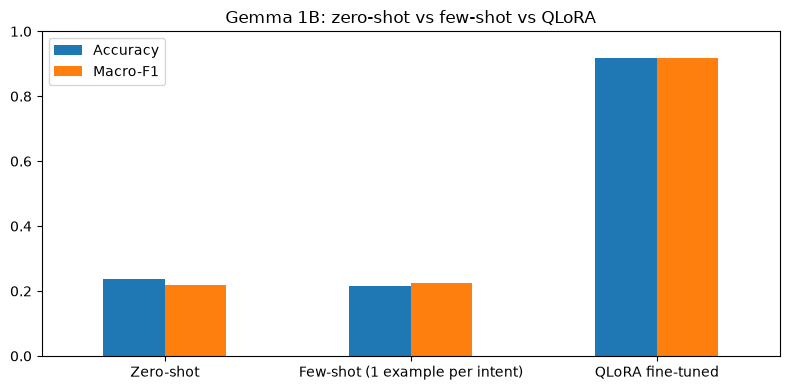

In [16]:
results[["Accuracy", "Macro-F1"]].plot.bar(
    rot=0, ylim=(0, 1), figsize=(8, 4), title="Gemma 1B: zero-shot vs few-shot vs QLoRA"
)
plt.tight_layout()

### Does each approach handle all intents equally well?

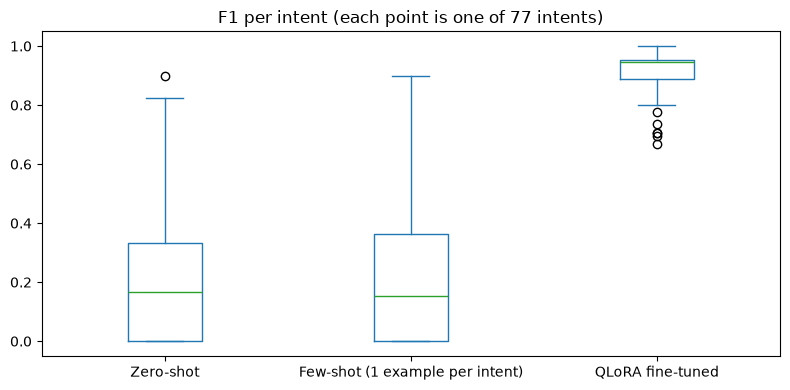

In [17]:
per_intent = pd.DataFrame(
    {
        name: per_intent_f1(small_test["label_text"].tolist(), small_test[col].tolist(), LABELS)
        for name, col in approaches.items()
    }
)
per_intent.plot.box(figsize=(8, 4), title="F1 per intent (each point is one of 77 intents)")
plt.tight_layout()

In [18]:
# The ten intents that remain hardest after fine-tuning.
per_intent.sort_values("QLoRA fine-tuned").head(10).round(2)

,Zero-shot,Few-shot (1 example per intent),QLoRA fine-tuned
top_up_failed,0.44,0.42,0.67
transfer_not_received_by_recipient,0.19,0.17,0.70
declined_transfer,0.15,0.10,0.71
pending_transfer,0.00,0.18,0.71
balance_not_updated_after_bank_transfer,0.32,0.13,0.74
card_payment_not_recognised,0.15,0.00,0.78
direct_debit_payment_not_recognised,0.33,0.33,0.80
pending_cash_withdrawal,0.18,0.33,0.82
transfer_timing,0.52,0.36,0.82
top_up_reverted,0.00,0.00,0.82


A 77 × 77 confusion matrix is hard to read, so we list the most frequent confusions of each approach instead.

In [19]:
confusions = {
    name: top_confusions(small_test["label_text"].tolist(), small_test[col].tolist(), n=5)
    for name, col in approaches.items()
}
pd.concat(confusions, names=["Approach", "Rank"])

True intent  \
Approach                        Rank                                            
Zero-shot                       0                         why_verify_identity   
                                1                              pending_top_up   
                                2                                 pin_blocked   
                                3                               top_up_limits   
                                4            card_payment_wrong_exchange_rate   
Few-shot (1 example per intent) 0                            compromised_card   
                                1                          passcode_forgotten   
                                2                    virtual_card_not_working   
                                3                       edit_personal_details   
                                4                        pending_card_payment   
QLoRA fine-tuned                0                            pending_transfer   
                                1     balance_not_updated_after_bank_transfer   
                                2                 card_payment_not_recognised   
                                3                           declined_transfer   
                                4         direct_debit_payment_not_recognised   

                                                                Predicted  \
Approach                        Rank                                        
Zero-shot                       0                      verify_my_identity   
                                1                           top_up_failed   
                                2                                 invalid   
                                3          top_up_by_bank_transfer_charge   
                                4                           exchange_rate   
Few-shot (1 example per intent) 0                                 invalid   
                                1                                 invalid   
                                2                                 invalid   
                                3                                 invalid   
                                4                                 invalid   
QLoRA fine-tuned                0      transfer_not_received_by_recipient   
                                1                         transfer_timing   
                                2     direct_debit_payment_not_recognised   
                                3                         failed_transfer   
                                4          cash_withdrawal_not_recognised   

                                      Count  
Approach                        Rank         
Zero-shot                       0        10  
                                1         9  
                                2         9  
                                3         9  
                                4         8  
Few-shot (1 example per intent) 0        10  
                                1        10  
                                2        10  
                                3         9  
                                4         9  
QLoRA fine-tuned                0         3  
                                1         2  
                                2         2  
                                3         2  
                                4         2

## Reflect

Use the evidence above (the results tables, charts and examples) to answer:

- Which approach gained most, and what makes a 77-intent task hard to solve with prompting alone?
- Look at the most confused intent pairs. Are these model errors, or are some intents genuinely hard to tell apart?
- Did the few-shot examples help? Whatever the answer, what in the prompts or the task could explain it?
- How many labelled examples per intent would you need before fine-tuning pays off, and how would you test it?

## What Next?

Ways to build on this project:

- Build a Swahili banking intent classifier with the INJONGO intent data, using the same zero-shot, few-shot and QLoRA comparison
- Choose few-shot examples by similarity to the query with EmbeddingGemma instead of at random
- Let the model answer "unsure" and pass those queries to a human agent; measure how many errors this catches
- Connect the classifier to a reply generator to build a full support pipeline (see [Build a Customer Support Response Generator](https://github.com/aims-ai-research-foundations/airf-capstone-project-recipes/tree/main/projects/customer-support-response-generation/))